# Crop Recommendation System

This notebook focuses on recommending the best crop to plant based on chemical and physical properties of the soil and environment. The dataset includes:
- `N`: Ratio of Nitrogen content in soil
- `P`: Ratio of Phosphorus content in soil
- `K`: Ratio of Potassium content in soil
- `temperature`: Temperature in degrees Celsius
- `humidity`: Relative humidity in %
- `ph`: pH value of the soil
- `rainfall`: Rainfall in mm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import pickle
import warnings
warnings.filterwarnings('ignore')

### 1. Data Loading

In [2]:
df = pd.read_csv('dataset/Crop_recommendation.csv')
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### 2. Data Exploration

In [3]:
print("Shape of dataset:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())

Shape of dataset: (2200, 8)
Duplicate rows: 0
Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [4]:
df['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

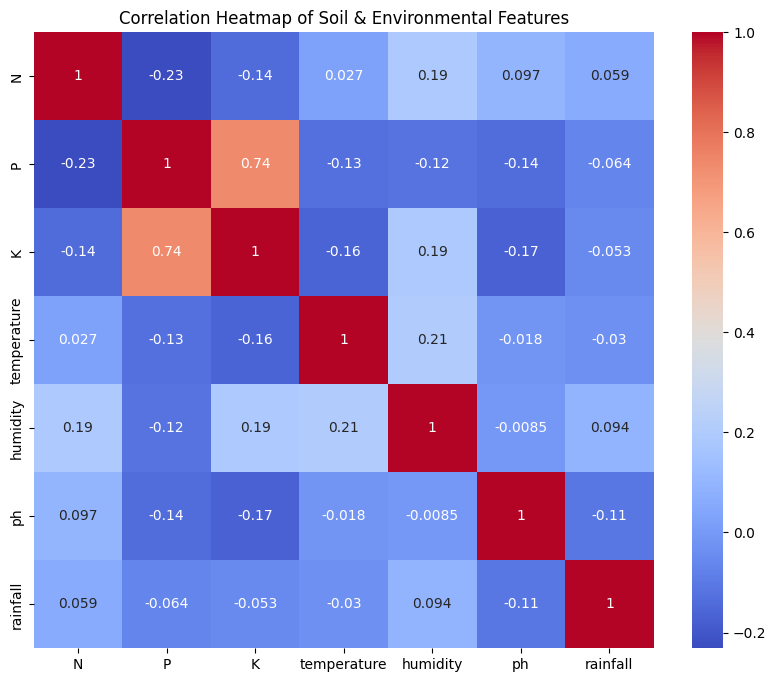

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Soil & Environmental Features')
plt.show()

### 3. Data Preprocessing

In [6]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 4. Model Training & Comparison

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100)
}

model_accuracies = []
for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    model_accuracies.append({'Model': name, 'Accuracy': acc})

acc_df = pd.DataFrame(model_accuracies).sort_values(by='Accuracy', ascending=False)
acc_df

,Model,Accuracy
1,Naive Bayes,0.995455
4,Random Forest,0.993182
3,Decision Tree,0.986364
0,Logistic Regression,0.968182
2,SVM,0.961364


### 5. Final Model Evaluation (Naive Bayes)

In [8]:
final_model = GaussianNB()
final_model.fit(X_train, y_train)
preds = final_model.predict(X_test)

print("Final Model: Naive Bayes")
print("Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))

Final Model: Naive Bayes
Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      1.00      1.00        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
  

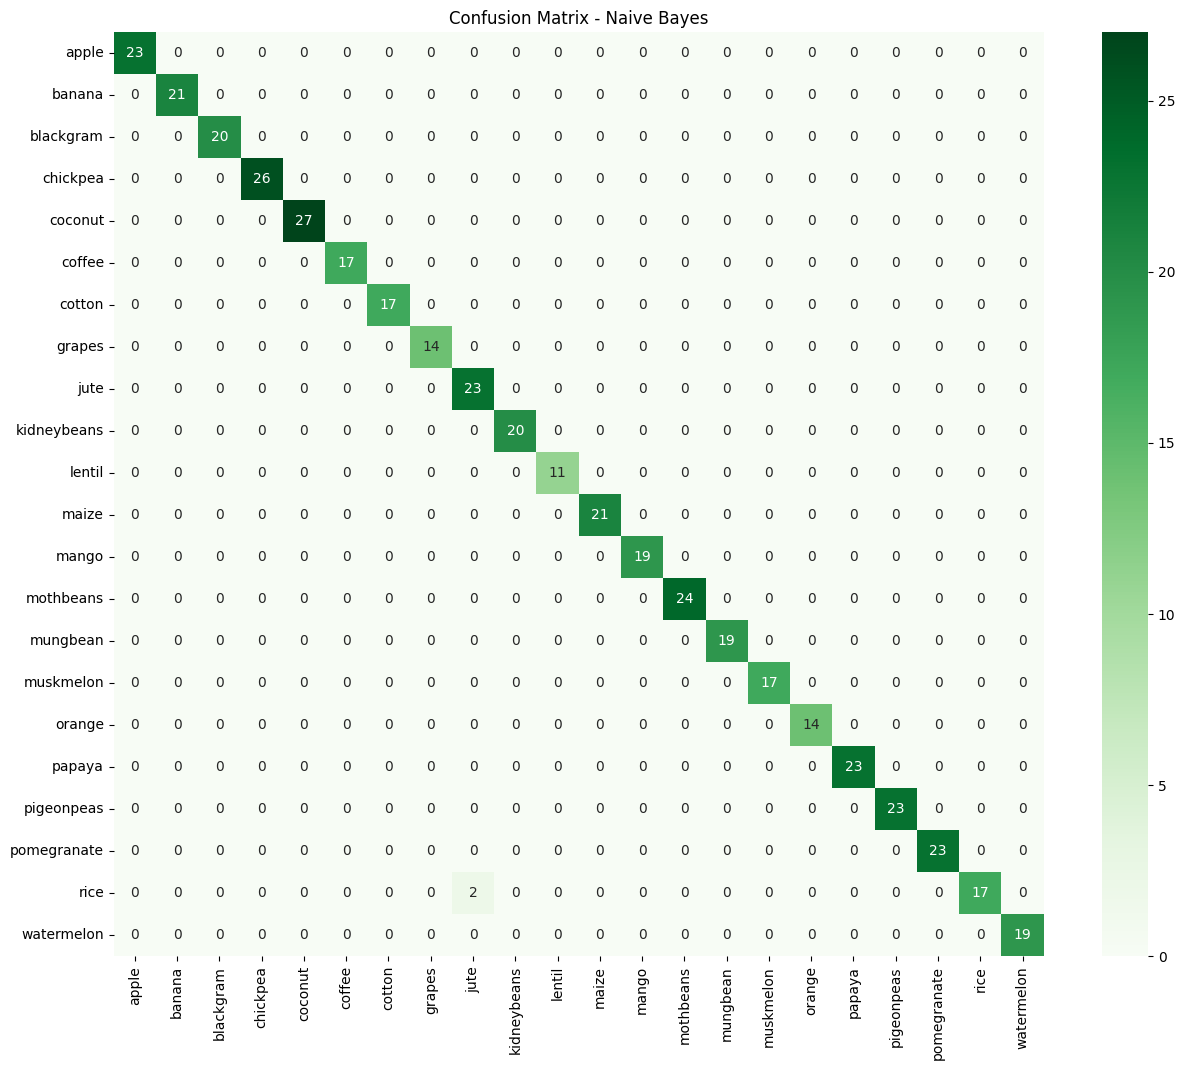

In [9]:
plt.figure(figsize=(15, 12))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Greens', 
            xticklabels=final_model.classes_, yticklabels=final_model.classes_)
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 6. Saving the Model

In [10]:
import os
if not os.path.exists('models'):
    os.makedirs('models')
with open('models/crop_recommendation_nb.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("Model saved as 'models/crop_recommendation_nb.pkl'")

Model saved as 'models/crop_recommendation_nb.pkl'
